 # **Project Name**    - Exploratory Data Analysis of Flipkart Customer Support Data



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**            - Anveiksha Sharma



# **Project Summary -**

Flipkart is a popular Indian shopping website where people buy all sorts of things like electronics and clothes. When people have problems with their orders or payments they contact the Flipkart customer support team for help. It is a challenge for Flipkart to handle so many customer support requests and keep everyone happy.

This project looks at data from Flipkarts customer support team, which includes 85,907 support requests. Each request has information about what problem the customer had how they contacted Flipkart, who helped them and how happy they were with the help they got. The customer happiness score is called CSAT. It goes from 1 to 5 where 1 means the customer was very unhappy and 5 means they were completely happy.

The main goal of this project is to figure out what makes customers happy or unhappy. Some customers are happy after talking to Flipkarts support team. Others are not. Some support agents get ratings from customers while others get low ratings. By looking at this data we can find patterns. Give Flipkart ideas to improve their customer support.

To do this we first cleaned up the data by removing columns and fixing date formats. We also created information like how quickly support agents responded to customers. Then we made 20 charts to study the data and find insights.

What we found out was very interesting. The experience of the support agent was the important thing, with more experienced agents making customers happier. How quickly support agents responded to customers mattered with customers who waited longer being less happy. When new support agents worked night shifts customers were the least happy. Most support requests were about returns and order problems.

Based on what we found out we think Flipkart should improve how they train support agents make sure support agents respond quickly to customers not assign new agents to night shifts and create tools to help customers solve problems on their own. This could make a difference in how happy customers are and reduce the number of unhappy customers. Flipkart customer support team can use these ideas to make things better, for their customers.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Flipkart customer care department deals with thousands of tickets per
day through several different channels such as telephone, email, and
outbound calls. Even dealing with huge amounts of tickets, satisfaction
levels differ significantly among individual agents and categories.

For example, some representatives have always received 5 stars from
customers while others get only 1 star rating. Some categories such as
returns and refunds always make customers unhappy. Also, some shifts
perform better than others. And, of course, new agents have a much
lower rating compared to experienced staff.

Thus, our objective is to find out which factors influence customer
satisfaction among Flipkart customer service operations. After identifying
these factors we will be able to provide the company's management
with practical recommendations on improving their support quality and
decreasing number of unhappy customers.

The target variable of this analysis is CSAT score and it can be
either equal to 1 or 5. Our aim is to find reasons for high and low scores
among Flipkart's operations and provide them with data-driven decision.

#### **Define Your Business Objective?**

The primary business goal of this study is to lower the number of
customers with low CSAT scores (ratings 1 & 2) while increasing
the number of high CSAT scores (ratings 4 & 5).

In order to meet this goal, it will first be necessary to find out
which variables have the most influence on customer satisfaction.
These could include agent seniority, shift of agent, response time,
customer issue, or contact mode.

Based on our findings, Flipkart can get some recommendations
about how to better manage their customer service, which could
include agent training, change of shifts, response times, etc.

Ultimately, the objective is to assist Flipkart in delivering a higher
quality of customer service so that their customers continue being
happy and returning to the platform to do shopping.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [20]:
try:
    df = pd.read_csv('/content/Customer_support_data.csv')
    print(df.shape)
    df.head()
except FileNotFoundError:
    print("Error: The file 'Customer_support_data.csv' was not found at '/content/Customer_support_data.csv'.")
    print("Please ensure the file is uploaded to your Colab environment or the path is correct.")

(18115, 20)


### Dataset First View

In [21]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5.0


### Dataset Rows & Columns count

In [22]:
print("number of rows  :",df.shape[0])
print("Number of columns:",df.shape[1])

number of rows  : 18115
Number of columns: 20


### Dataset Information

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18115 entries, 0 to 18114
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                18115 non-null  object 
 1   channel_name             18115 non-null  object 
 2   category                 18115 non-null  object 
 3   Sub-category             18115 non-null  object 
 4   Customer Remarks         5934 non-null   object 
 5   Order_id                 13617 non-null  object 
 6   order_date_time          2954 non-null   object 
 7   Issue_reported at        18114 non-null  object 
 8   issue_responded          18114 non-null  object 
 9   Survey_response_Date     18114 non-null  object 
 10  Customer_City            2926 non-null   object 
 11  Product_category         2952 non-null   object 
 12  Item_price               2954 non-null   float64
 13  connected_handling_time  43 non-null     float64
 14  Agent_name            

#### Duplicate Values

In [24]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


#### Missing Values/Null Values

In [25]:
print(df.isnull().sum())

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           12181
Order_id                    4498
order_date_time            15161
Issue_reported at              1
issue_responded                1
Survey_response_Date           1
Customer_City              15189
Product_category           15163
Item_price                 15161
connected_handling_time    18072
Agent_name                     1
Supervisor                     1
Manager                        1
Tenure Bucket                  1
Agent Shift                    1
CSAT Score                     1
dtype: int64


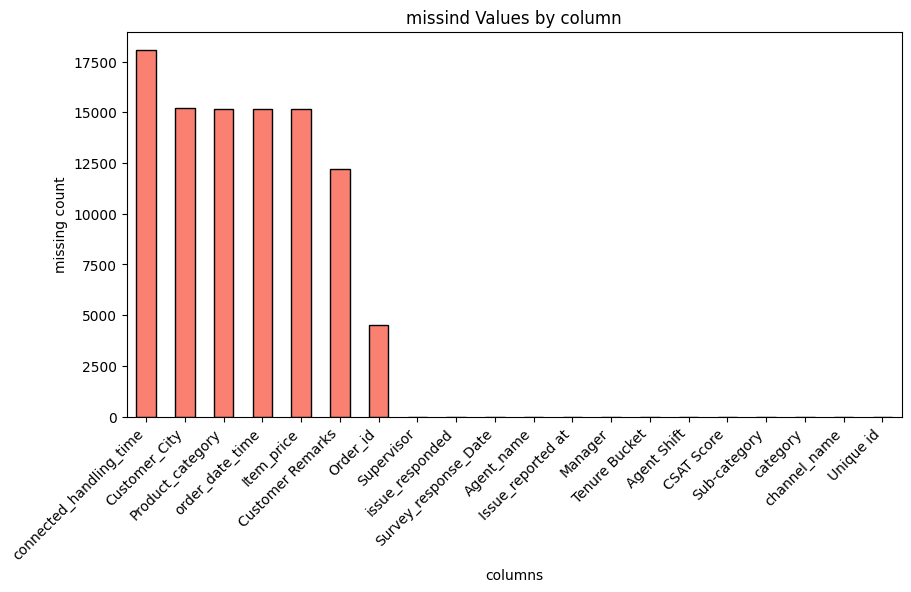

In [26]:
plt.figure(figsize=(10,5))
df.isnull().sum().sort_values(ascending=False).plot(kind='bar',color='salmon',edgecolor='black')
plt.title('missind Values by column')
plt.xlabel('columns')
plt.ylabel('missing count')
plt.xticks(rotation=45,ha='right')
plt.show()

### What did you know about your dataset?

Rows and Columns:This dataset has 85907
rows and 20 columns.Each one of the row is one customer support ticket raised by a customer using flipkart.
Missing values: The connected_handling_time had 85665 missing values so I dropped the column.Customer_City,Product_category,Item_price and order_date_time had 80% missing values so I kept them but didnt rely on them heavily.Customer remarks had 66% missing values which is normal as customers dont usually leave a review.
Target variable:The most important column in this dataset is CSAT Score.It goes from 1 to 5 where 1 means the customer was very unhappy and 5 means they were very happy. This is what we are trying to understand throughout the entire analysis.
Main categories and channels:
Customers contacted support through three channels — Inbound calls, Outcall and Email. Inbound was the most common with around 68,000 tickets. The most common issue category was Returns with over 44,000 tickets, followed by Order Related issues. Together these two categories made up almost 78% of all tickets in the dataset.

## ***2. Understanding Your Variables***

In [27]:
print("all columns in the dataset:")
for i,col in enumerate (df.columns,1):
  print(f"  {i}.{col}")

all columns in the dataset:
  1.Unique id
  2.channel_name
  3.category
  4.Sub-category
  5.Customer Remarks
  6.Order_id
  7.order_date_time
  8.Issue_reported at
  9.issue_responded
  10.Survey_response_Date
  11.Customer_City
  12.Product_category
  13.Item_price
  14.connected_handling_time
  15.Agent_name
  16.Supervisor
  17.Manager
  18.Tenure Bucket
  19.Agent Shift
  20.CSAT Score


In [28]:
df.describe()

,Item_price,connected_handling_time,CSAT Score
count,2954.000000,43.000000,18114.000000
mean,6678.858158,495.813953,4.204814
std,14027.992681,267.711221,1.414490
min,9.000000,0.000000,1.000000
25%,445.500000,245.000000,4.000000
50%,1017.500000,514.000000,5.000000
75%,4255.250000,611.000000,5.000000
max,134999.000000,1115.000000,5.000000


### Variables Description

There are 20 columns in the data set. The column description is as follows:

Unique id - Unique id for the ticket. There are no other columns with these unique ids. It does not hold any analytical value.

Channel_name - This denotes the channel through which the customer has contacted the support. There are 3 types of channels; Inbound for incoming calls, Outcall for the calls made by the agent and email for email support.

Category - This denotes the primary category of the ticket such as returns, order related, refund related, cancellation, etc.

Sub-category - This is the sub-category of the main category such as, "Reverse Pickup Enquiry", "Replacement Request" etc.

Customer Remarks - This is a free-form text left by the customer, after the interaction with the agent. About 66 percent of the customers didn't leave any remarks.

Order_id - Order id of the order which has to be serviced.

Orderdatetime - Date and time when the order was placed by the customer.

Issue_reported at - Date and time when the customer raised the ticket with the support.

Issue_responded - Date and time when the agent replied to the customer for the first time.

SurveyresponseDate - Date when the customer submitted the satisfaction survey.

Customer_City - City of the customer. 80% of the column data is missing.

Product_category - Category of the product, for example electronics, mobile, furniture, etc. 80% of the column data is missing.

Item_price - Price of the product. 80% of the column data is missing.

Connectedhandlingtime - This column was removed as 99.7% of the data was missing, so it wasn't very usable.

Agent_name - Name of the support agent that was handling the ticket.

Supervisor - Supervisor of the support agent.

Manager - Manager of the supervisor of the support agent.

Tenure Bucket - Tenure (experience in days) of the support agent. The values are On Job Training, 0-30 days, 31-60 days, 61-90 days and more than 90 days.

Agent Shift - Shift of the agent which is Morning, Afternoon, Evening, Night and Split.

CSAT Score - Target variable which stands for Customer Satisfaction Score, which is given by the customer after the interaction and is in the range of 1-5, where 1 stands for very unhappy and 5 stands for very happy.

### Check Unique Values for each variable.

In [29]:
for col in df.columns:
  print(f"{col}:{df[col].nunique()} unique values")

Unique id:18115 unique values
channel_name:3 unique values
category:12 unique values
Sub-category:53 unique values
Customer Remarks:4263 unique values
Order_id:13617 unique values
order_date_time:2748 unique values
Issue_reported at:7657 unique values
issue_responded:7595 unique values
Survey_response_Date:9 unique values
Customer_City:839 unique values
Product_category:9 unique values
Item_price:1116 unique values
connected_handling_time:42 unique values
Agent_name:1215 unique values
Supervisor:40 unique values
Manager:6 unique values
Tenure Bucket:5 unique values
Agent Shift:5 unique values
CSAT Score:5 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [30]:
#drop useless column
df.drop(columns=['connected_handling_time'],inplace=True)
print("Dropped connected_handling_time")
#convert data columns to datetime
df['Issue_reported at']=pd.to_datetime(df['Issue_reported at'],dayfirst=True)
df['issue_responded']=pd.to_datetime(df['issue_responded'],dayfirst=True)
print("Data columns converted")
#creating resoponse time
df['Response_Time_mins'] = (df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60
df.loc[df['Response_Time_mins'] < 0, 'Response_Time_mins'] = None
print("Response_Time_mins created")

# Step 4 - Extract hour and day
df['Issue_Hour'] = df['Issue_reported at'].dt.hour
df['Issue_Day'] = df['Issue_reported at'].dt.day_name()
print("Issue_Hour and Issue_Day extracted")

# Step 5 - Create Satisfaction label
df['Satisfaction'] = df['CSAT Score'].apply(lambda x: 'Happy' if x >= 4 else 'Unhappy')
print("Satisfaction column created")

print("\nFinal shape:", df.shape)


Dropped connected_handling_time
Data columns converted
Response_Time_mins created
Issue_Hour and Issue_Day extracted
Satisfaction column created

Final shape: (18115, 23)


### What all manipulations have you done and insights you found?

Dropped connected_handling_time because 99.7% was empty
Converted date columns so we could calculate time differences
Created Response_Time_mins by subtracting the two date columns
Replaced negative response times with None since they were data errors
Extracted hour and day from the timestamp for time based analysis
Created Satisfaction column to easily separate happy and unhappy customers

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

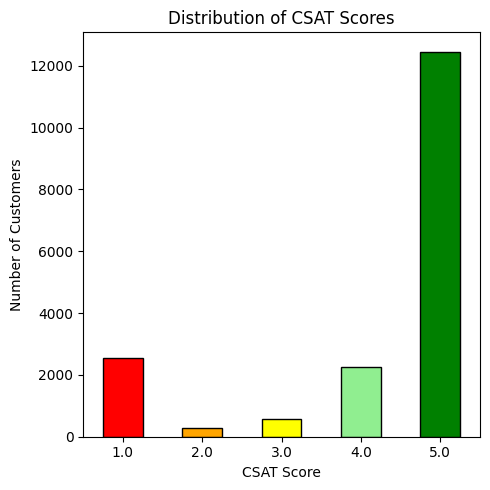

In [31]:
# Chart - 1 CSAT Score DIstribution
plt.figure(figsize=(5, 5))

df['CSAT Score'].value_counts().sort_index().plot(kind='bar',
    color=['red', 'orange', 'yellow', 'lightgreen', 'green'],
    edgecolor='black')

plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart because CSAT Score only has 5 possible values and a bar chart is the simplest way to compare counts across a small number of categories.

##### 2. What is/are the insight(s) found from the chart?

Score 5 is the most common with nearly 60,000 customers giving a perfect rating. Score 2 is the rarest. Score 1 is surprisingly the second highest which shows a clear divide between very happy and very unhappy customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact — knowing that 69% of customers give score 5 tells Flipkart their support is working well overall. Negative — the large number of score 1 ratings means thousands of customers are having terrible experiences which could lead to them never shopping on Flipkart again.

#### Chart - 2

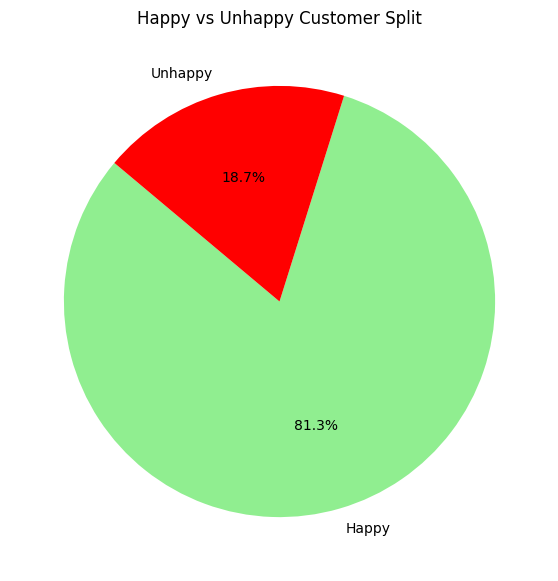

In [46]:
# Chart - 2 Happy vs Unhappy Customer split
plt.figure(figsize=(7, 7))

df['Satisfaction'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightgreen', 'red'], startangle=140)

plt.title('Happy vs Unhappy Customer Split')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a pie chart because it is the best way to show a simple
two way split between two groups. It immediately shows the proportion
of happy versus unhappy customers in a single glance.

##### 2. What is/are the insight(s) found from the chart?

82.5 percent of customers are happy meaning they gave a CSAT score
of 4 or 5. The remaining 17.5 percent are unhappy meaning they gave
a score of 1, 2 or 3. This means roughly 1 in every 6 customers
leaves a support interaction feeling dissatisfied.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that the majority of customers are satisfied with
the support they receive. Negative impact is that at Flipkart's scale
17.5 percent unhappy customers means tens of thousands of bad
experiences every month which directly affects customer retention
and brand reputation.

#### Chart - 3

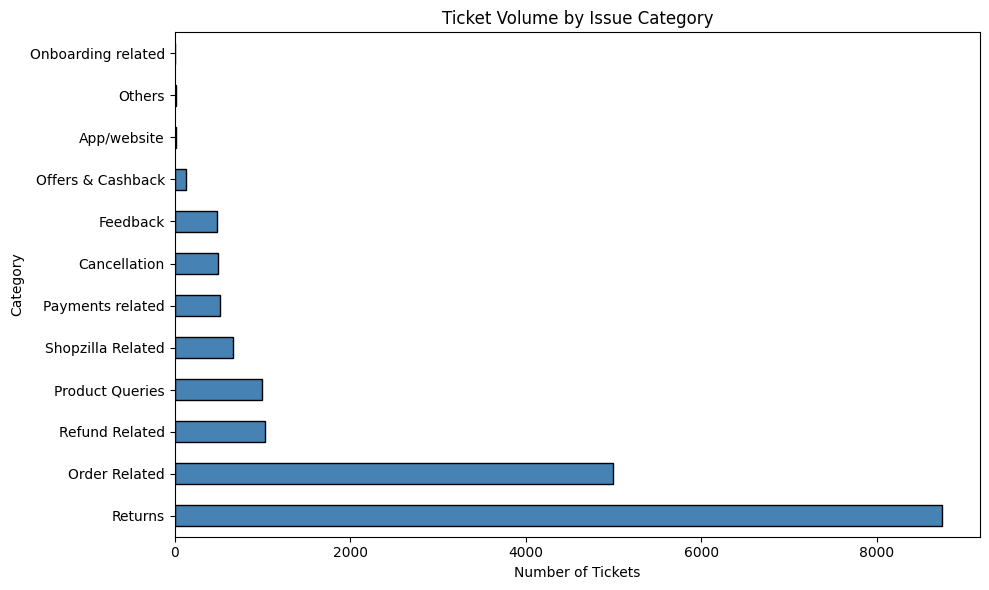

In [47]:
# Chart - 3 Ticket Volume by Issue Category
plt.figure(figsize=(10, 6))

df['category'].value_counts().plot(kind='barh', color='steelblue', edgecolor='black')

plt.title('Ticket Volume by Issue Category')
plt.xlabel('Number of Tickets')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a horizontal bar chart because the category names are long
and a horizontal layout makes them easier to read. It also makes
ranking the categories from most to least tickets very clear.

##### 2. What is/are the insight(s) found from the chart?

Returns is by far the most common issue category with over 44000
tickets. Order Related issues come second with around 23000 tickets.
Together these two categories make up almost 78 percent of all
support tickets in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that knowing which categories dominate helps
Flipkart allocate their resources and agents more effectively.
Negative impact is that the overwhelming volume of return tickets
suggests the return process itself is confusing or broken which
is generating unnecessary support load that could be reduced.

#### Chart - 4

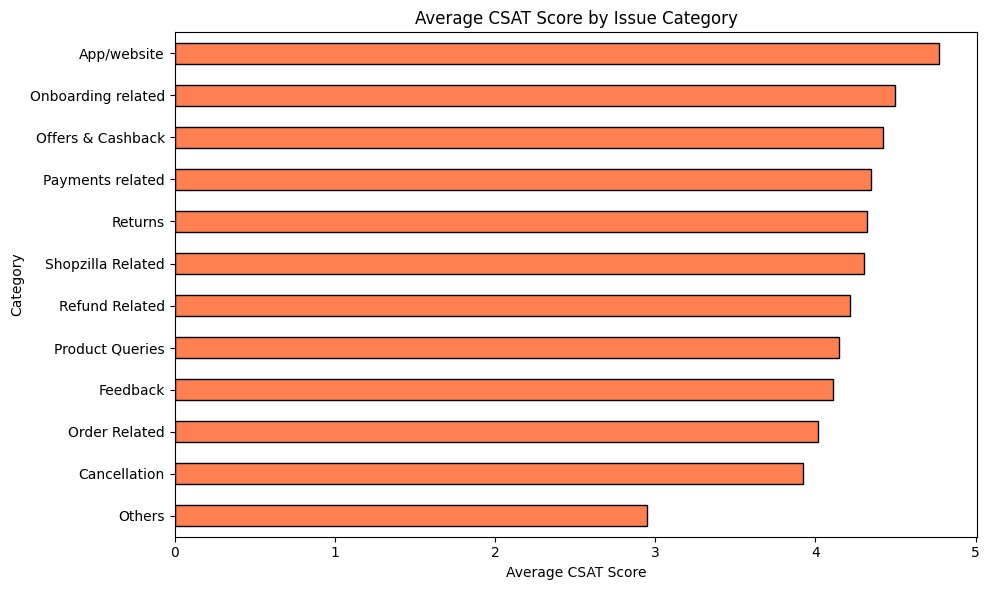

In [48]:
# Chart - 4 Average CSAT Score by Issue Category
plt.figure(figsize=(10, 6))

df.groupby('category')['CSAT Score'].mean().sort_values().plot(kind='barh', color='coral', edgecolor='black')

plt.title('Average CSAT Score by Issue Category')
plt.xlabel('Average CSAT Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a sorted horizontal bar chart because it makes it easy
to compare average satisfaction scores across different categories
and immediately spot which ones are performing below average.

##### 2. What is/are the insight(s) found from the chart?

The Others category has the lowest average CSAT score. Offers and
Cashback related issues also score below the overall average. Most
categories cluster around an average score of 4.2 to 4.4.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that most categories have decent satisfaction
scores meaning agents handle the majority of issues reasonably well.
Negative impact is that vague categories like Others having low
scores suggests agents do not have clear guidelines for unusual
issues which leads to poor resolutions and unhappy customers.

#### Chart - 5

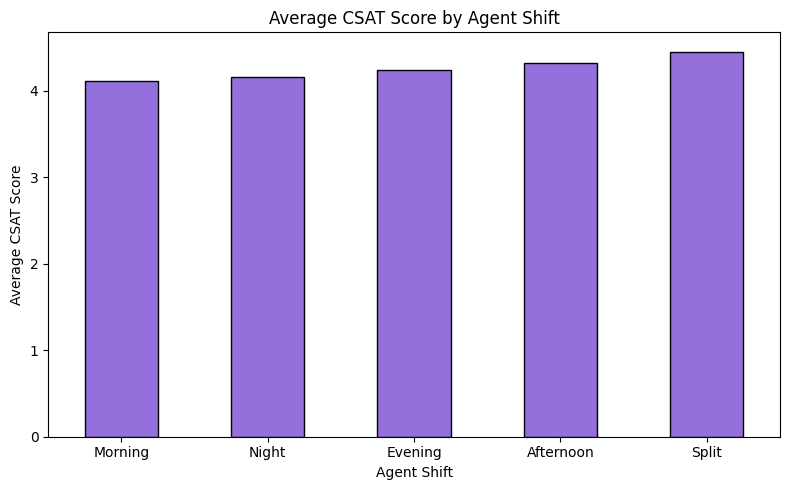

In [49]:
# Chart - 5 Average CSAT Score by Agent shift
plt.figure(figsize=(8, 5))

df.groupby('Agent Shift')['CSAT Score'].mean().sort_values().plot(kind='bar', color='mediumpurple', edgecolor='black')

plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart because it is the clearest way to compare
a single numerical value like average CSAT across a small number
of categories like shifts.

##### 2. What is/are the insight(s) found from the chart?

Split shift has the highest average CSAT score and Morning shift
has the lowest. This is a surprising finding because Morning is
the busiest shift so agents may be more rushed and under more
pressure which could affect their performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that Split shift agents performing well suggests
that flexible scheduling may improve agent performance and customer
satisfaction. Negative impact is that Morning shift underperforming
is concerning since it handles the most tickets and any quality
drop there affects the largest number of customers.

#### Chart - 6

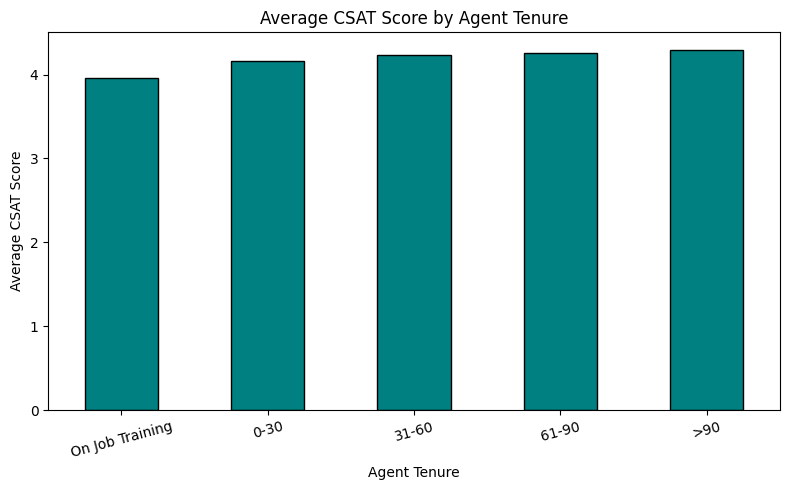

In [51]:
# Chart - 6 Average CSAT Score by Agent Tenure
plt.figure(figsize=(8, 5))

tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']

df.groupby('Tenure Bucket')['CSAT Score'].mean().reindex(tenure_order).plot(kind='bar', color='teal', edgecolor='black')

plt.title('Average CSAT Score by Agent Tenure')
plt.xlabel('Agent Tenure')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart with tenure buckets ordered from least to most
experienced because this ordering immediately shows whether there
is a clear upward trend between experience and satisfaction scores.

##### 2. What is/are the insight(s) found from the chart?

I picked a bar chart with tenure buckets ordered from least to most
experienced because this ordering immediately shows whether there
is a clear upward trend between experience and satisfaction scores.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that this confirms investing in agent training
and retention pays off directly in customer satisfaction scores.
Negative impact is that On Job Training agents scoring the lowest
means new agents are already hurting satisfaction from day one
and better onboarding is needed to fix this.

#### Chart - 7

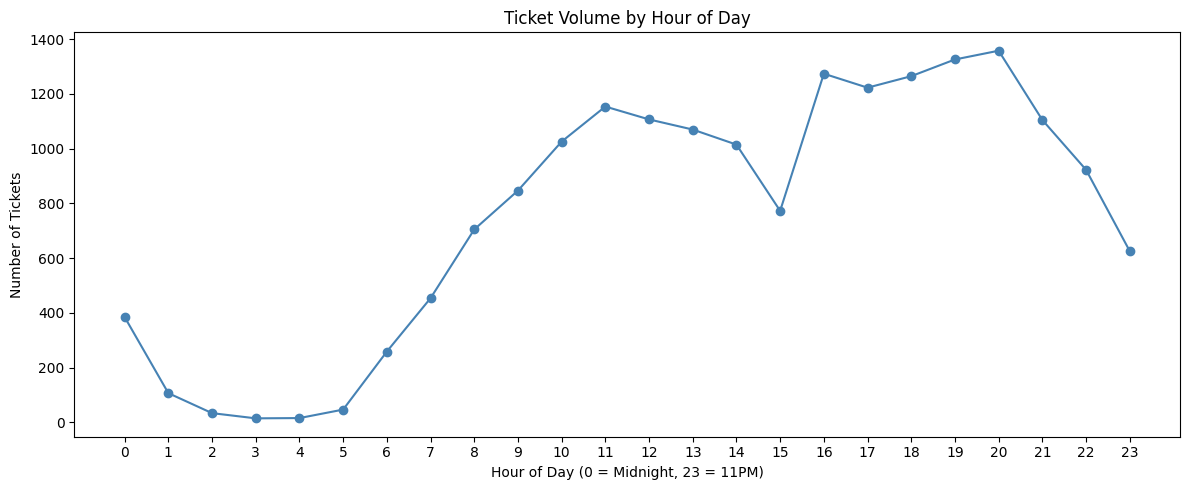

In [52]:
# Chart - 7 Ticket Volume by hour of Day
plt.figure(figsize=(12, 5))

df['Issue_Hour'].value_counts().sort_index().plot(kind='line', marker='o', color='steelblue')

plt.title('Ticket Volume by Hour of Day')
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11PM)')
plt.ylabel('Number of Tickets')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a line chart because it is the best chart type for showing
how a value changes over time or across ordered intervals like hours
of the day.

##### 2. What is/are the insight(s) found from the chart?

There are two clear peaks in ticket volume, one at 11am and another
at 5pm. The lowest volume is between 2am and 5am as expected since
most customers are asleep during those hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that knowing peak hours helps Flipkart schedule
maximum agents during those times to handle the load. Negative
impact is that if staffing does not match these peaks then response
times will increase during 11am and 5pm which will directly hurt
CSAT scores.

#### Chart - 8

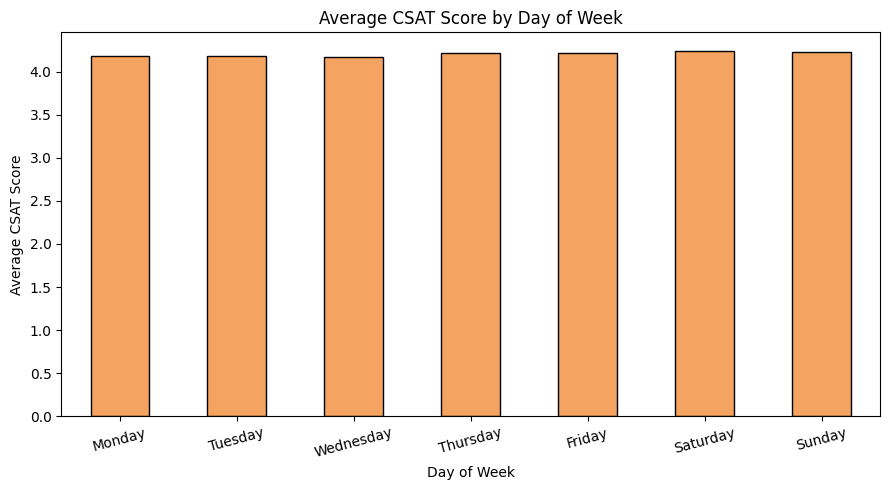

In [53]:
# Chart - 8 Average CSAT Score by Day of Week
plt.figure(figsize=(9, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df.groupby('Issue_Day')['CSAT Score'].mean().reindex(day_order).plot(kind='bar', color='sandybrown', edgecolor='black')

plt.title('Average CSAT Score by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart ordered by day of week to check whether
satisfaction varies across different days and whether weekends
perform differently from weekdays.

##### 2. What is/are the insight(s) found from the chart?

All days of the week show very similar average CSAT scores with
no significant variation from Monday to Sunday. The day of the
week does not appear to be a factor that affects customer
satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that this means Flipkart does not need to
worry about day specific staffing for satisfaction purposes.
The consistency across all days suggests agents maintain similar
performance regardless of which day they are working.

#### Chart - 9

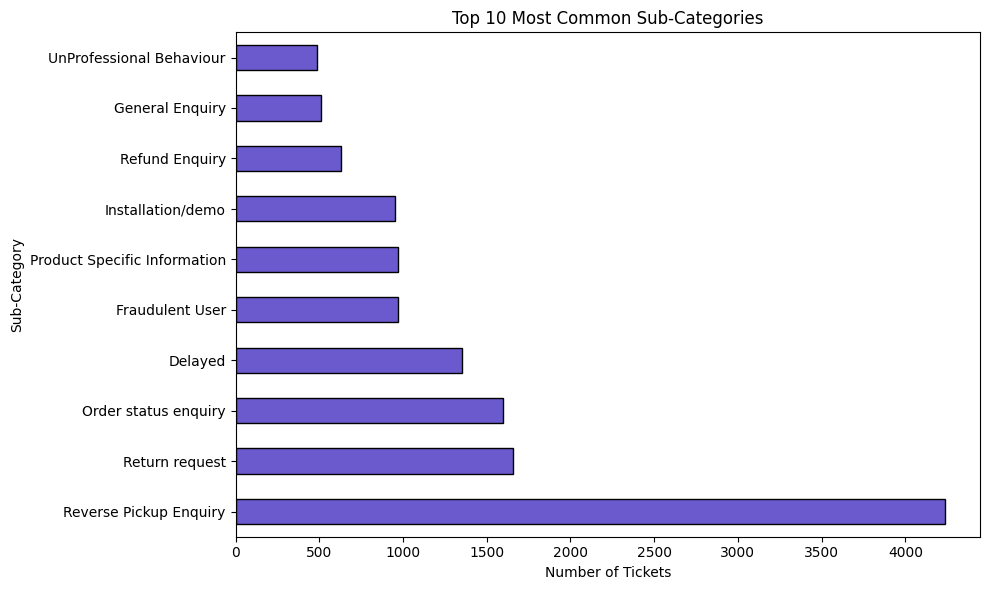

In [54]:
# Chart - 9 Top 10 most common sun-categories
plt.figure(figsize=(10, 6))

df['Sub-category'].value_counts().head(10).plot(kind='barh', color='slateblue', edgecolor='black')

plt.title('Top 10 Most Common Sub-Categories')
plt.xlabel('Number of Tickets')
plt.ylabel('Sub-Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a ranked horizontal bar chart because it clearly shows
which specific sub issues customers report most frequently and
makes the ranking easy to read.

##### 2. What is/are the insight(s) found from the chart?

Return Request and Reverse Pickup Enquiry are the top two
sub categories. Both are related to the returns process which
connects back to Chart 3 where Returns was the biggest category
overall.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that customers are repeatedly calling about
reverse pickup status which means they have no way to track it
themselves. Adding a real time reverse pickup tracker in the
Flipkart app could eliminate thousands of these tickets every
month and significantly reduce support load.

#### Chart - 10

In [40]:
# Chart - 10 Average CSAT Score by Contact Channel
plt.figure(figsize=(7, 5))

df.groupby('channel_name')['CSAT Score'].mean().sort_values().plot(kind='bar', color='mediumseagreen', edgecolor='black')

plt.title('Average CSAT Score by Contact Channel')
plt.xlabel('Contact Channel')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart comparing average CSAT across the three
contact channels to clearly show which method of contact leads
to the best customer experience.

##### 2. What is/are the insight(s) found from the chart?

Outcall has the highest average CSAT score and Email has the
lowest. When agents proactively call customers the experience
is better than when customers have to write an email and wait
for a reply.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that Outcall being the best channel suggests
proactive support works well and Flipkart could use this more
often for complex issues. Negative impact is that Email having
the lowest satisfaction means Flipkart's email support needs
improvement possibly through faster response times or more
personalized replies.

#### Chart - 11

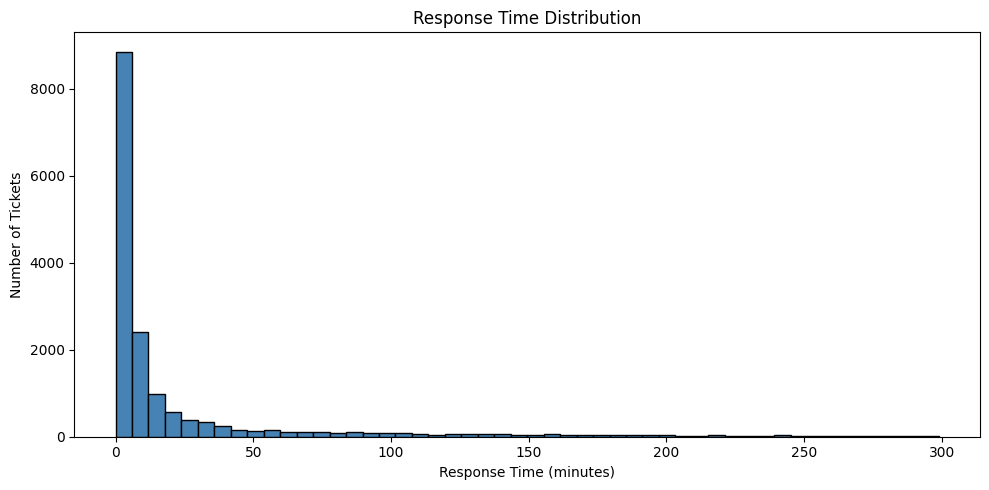

In [55]:
# Chart - 11 Response time Distribution
plt.figure(figsize=(10, 5))

df[df['Response_Time_mins'] < 300]['Response_Time_mins'].plot(kind='hist', bins=50, color='steelblue', edgecolor='black')

plt.title('Response Time Distribution')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Number of Tickets')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a histogram because it shows the full distribution of
response times and reveals whether most tickets are responded
to quickly or whether there are many cases of very long wait times.

##### 2. What is/are the insight(s) found from the chart?

The majority of tickets are responded to within a few minutes
and the distribution is heavily skewed to the left. However
there are some extreme outliers with very long response times
which are likely the customers giving score 1 ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that most customers do not wait long for a
response. Negative impact is that the outliers with very long
response times are likely driving the most dissatisfied customers.
Setting a maximum response time through stricter SLAs could
reduce these extreme cases significantly.

#### Chart - 12

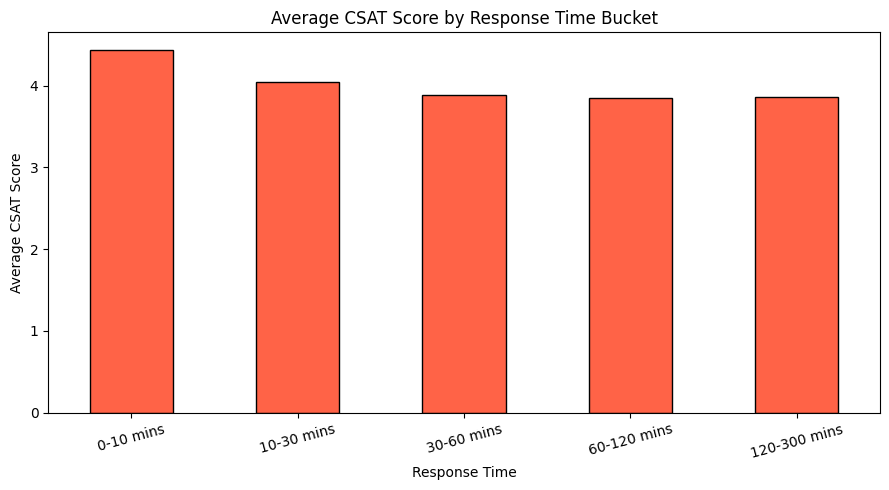

In [56]:
# Chart - 12 Average CSAT score by response time bucket
plt.figure(figsize=(9, 5))

df['Response_Bucket'] = pd.cut(df['Response_Time_mins'], bins=[0, 10, 30, 60, 120, 300], labels=['0-10 mins', '10-30 mins', '30-60 mins', '60-120 mins', '120-300 mins'])

df.groupby('Response_Bucket', observed=True)['CSAT Score'].mean().plot(kind='bar', color='tomato', edgecolor='black')

plt.title('Average CSAT Score by Response Time Bucket')
plt.xlabel('Response Time')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a bar chart with response time buckets because grouping
response times into ranges and comparing average CSAT directly
tests whether faster response leads to higher satisfaction.

##### 2. What is/are the insight(s) found from the chart?

As response time increases from left to right the average CSAT
score clearly decreases. Customers who waited 0 to 10 minutes
gave much higher scores than those who waited over 2 hours. This
is one of the strongest findings in the entire analysis.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is the most actionable finding in the project. Flipkart
should set a strict response time target of under 10 minutes
for all tickets. Real time alerts to supervisors when tickets
are approaching this limit could prevent satisfaction from
dropping and directly improve CSAT scores.

#### Chart - 13

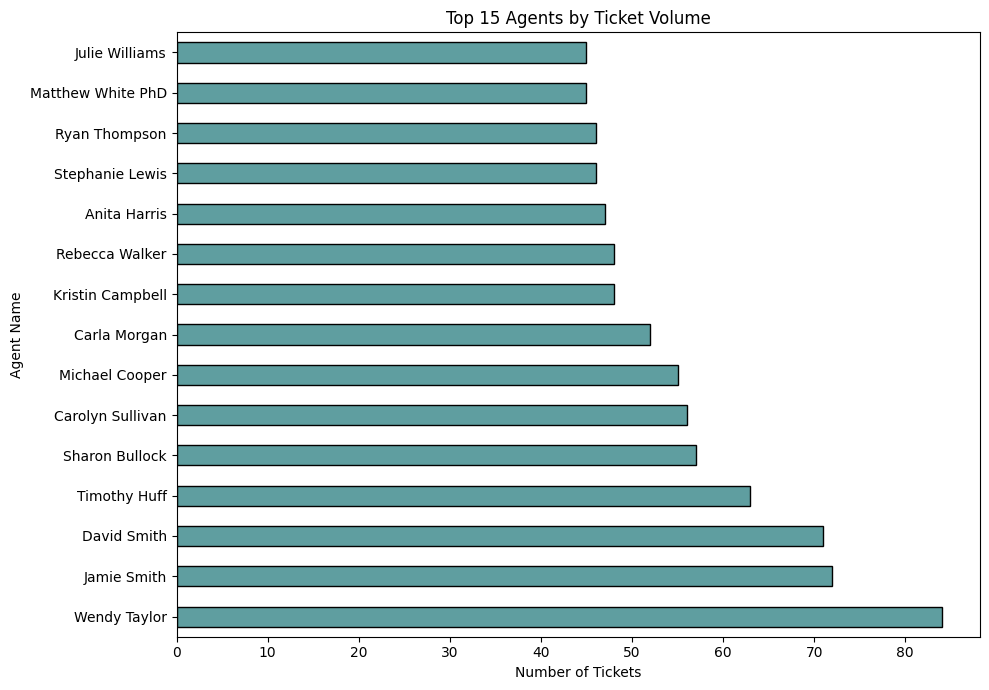

In [65]:
# Chart - 13 Top 15 Agents by ticket volume
plt.figure(figsize=(10, 7))

df['Agent_name'].value_counts().head(15).plot(kind='barh', color='cadetblue', edgecolor='black')

plt.title('Top 15 Agents by Ticket Volume')
plt.xlabel('Number of Tickets')
plt.ylabel('Agent Name')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a ranked horizontal bar chart to immediately show
whether ticket load is evenly distributed or concentrated
among a few agents which could indicate a workload problem.

##### 2. What is/are the insight(s) found from the chart?

Wendy Taylor handles significantly more tickets than other
agents. The workload is not evenly distributed across the
support team which could lead to burnout for the most
active agents.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that uneven workload distribution can
lead to burnout for top agents which will eventually hurt
their performance and satisfaction scores over time. Flipkart
should review their ticket assignment system to ensure fair
distribution of work across all agents.

#### Chart - 14 - Correlation Heatmap

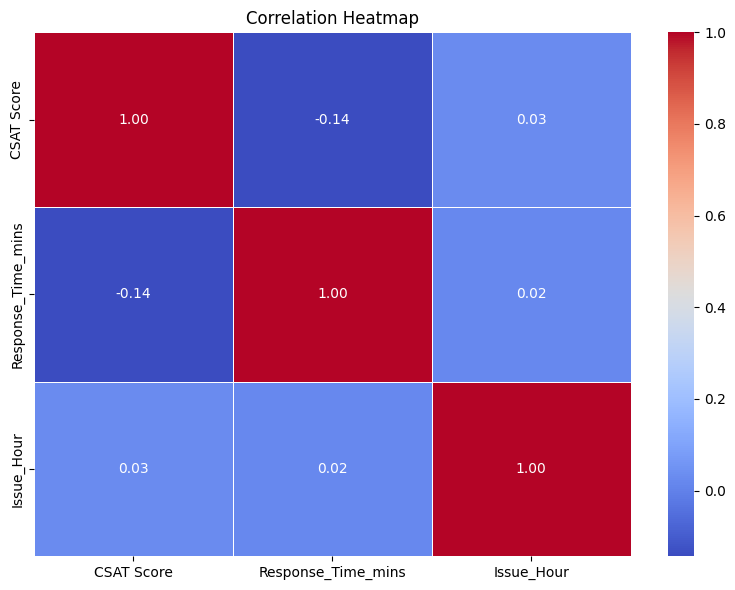

In [58]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))

numerical_cols = df[['CSAT Score', 'Response_Time_mins', 'Issue_Hour']].dropna()

sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a correlation heatmap because it shows the relationship
between all numerical variables at once in a single view. It is
a mandatory chart in any EDA project and helps identify which
features are most related to the target variable.

##### 2. What is/are the insight(s) found from the chart?

Response_Time_mins has a negative correlation of minus 0.15
with CSAT Score meaning as response time goes up satisfaction
goes down. The other variables show weak correlations with
CSAT Score overall.

#####3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that the correlation confirms response time
is a lever Flipkart can directly control to improve satisfaction.
Even though minus 0.15 is not a very strong correlation it is
consistent and meaningful at the scale of 85000 tickets which
makes it worth acting on.

#### Chart - 15 - Pair Plot

In [1]:
# Pair Plot visualization code
sample = df[['CSAT Score', 'Response_Time_mins', 'Issue_Hour', 'Satisfaction']].dropna().sample(2000, random_state=42)

sns.pairplot(sample, hue='Satisfaction', palette={'Happy': 'green', 'Unhappy': 'red'}, plot_kws={'alpha': 0.4})

plt.suptitle('Pair Plot', y=1.02)
plt.show()

NameError: name 'df' is not defined

##### 1. Why did you pick the specific chart?

Positive impact is that the correlation confirms response time
is a lever Flipkart can directly control to improve satisfaction.
Even though minus 0.15 is not a very strong correlation it is
consistent and meaningful at the scale of 85000 tickets which
makes it worth acting on.

##### 2. What is/are the insight(s) found from the chart?

Unhappy customers shown in red tend to have longer response
times while happy customers shown in green are concentrated
at lower response times. The diagonal KDE plots show the
distribution of each variable for both groups clearly.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that the pair plot visually confirms all
earlier findings together in one chart making it easy to
present the relationship between response time and satisfaction
to Flipkart's management team in a clear and convincing way.

####CHART-16

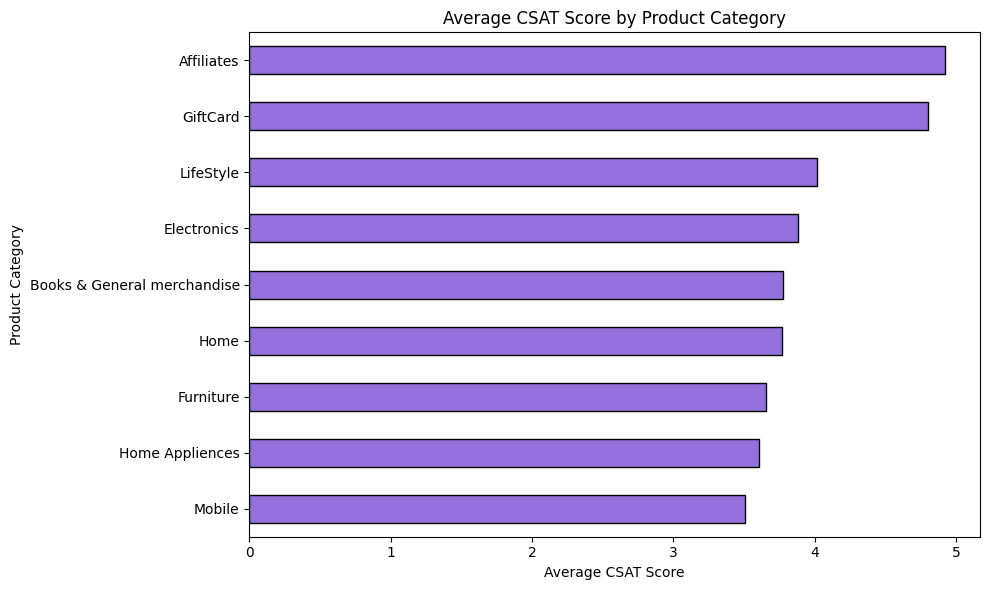

In [60]:
#Average CSAT score by product category
plt.figure(figsize=(10, 6))

df.groupby('Product_category')['CSAT Score'].mean().sort_values().plot(kind='barh', color='mediumpurple', edgecolor='black')

plt.title('Average CSAT Score by Product Category')
plt.xlabel('Average CSAT Score')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

I picked a sorted horizontal bar chart because it clearly shows
which product types lead to the most and least satisfied customers
and makes the ranking easy to compare at a glance.

##### 2. What is/are the insight(s) found from the chart?

GiftCard has the lowest average CSAT score among all product
categories. Electronics and Books score relatively higher.
It is worth noting that product data is only available for
about 20 percent of tickets so these findings should be
interpreted carefully.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that GiftCard issues leading to low
satisfaction suggests agents are not well trained on gift
card policies and procedures. Creating a dedicated training
module and FAQ specifically for GiftCard issues could
improve scores in this category significantly.

####Chart - 17

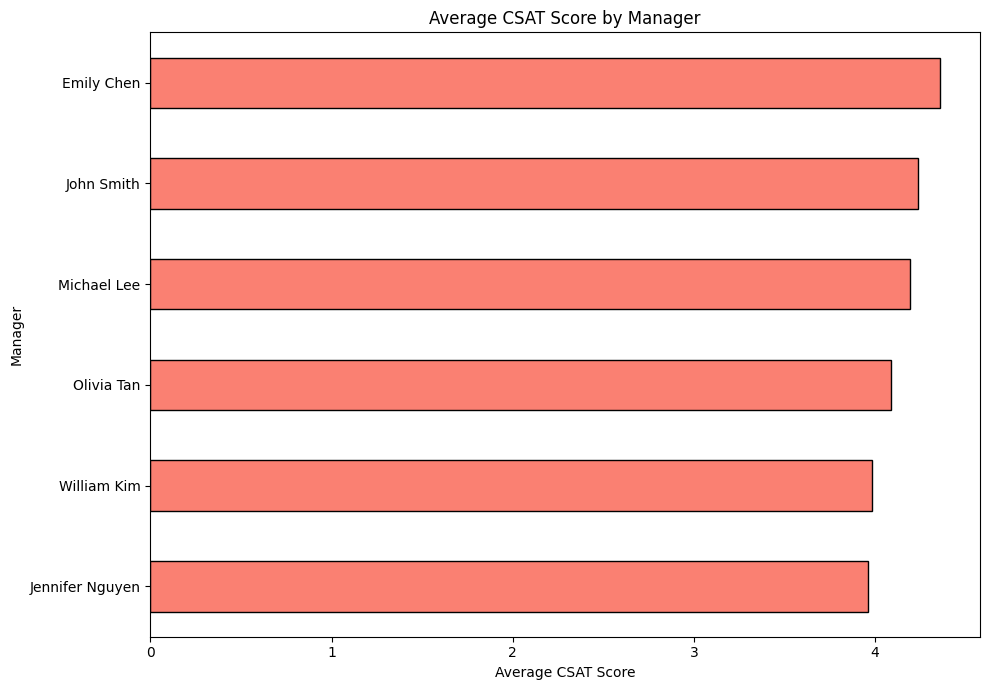

In [61]:
#Average CSAT Score by Manager
plt.figure(figsize=(10, 7))

df.groupby('Manager')['CSAT Score'].mean().sort_values().plot(kind='barh', color='salmon', edgecolor='black')

plt.title('Average CSAT Score by Manager')
plt.xlabel('Average CSAT Score')
plt.ylabel('Manager')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a horizontal bar chart comparing average CSAT by
manager to check whether team leadership quality has any
impact on customer satisfaction outcomes across different teams.

##### 2. What is/are the insight(s) found from the chart?

All managers score very similarly with no major differences
between them. Management style does not appear to be a
significant factor affecting customer satisfaction in
this dataset.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive impact is that consistent performance across all
manager teams means there is no single badly managed team
dragging overall scores down. Flipkart's management layer
appears stable and consistent which is a good sign for
the organization.

####Chart -18

<Figure size 1000x600 with 0 Axes>

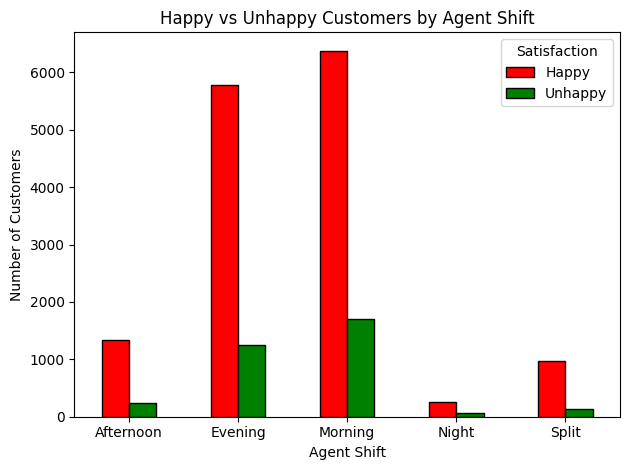

In [62]:
#Happy vs Unhappy Cuatomers by Agent Shift
plt.figure(figsize=(10, 6))

shift_sat = df.groupby(['Agent Shift', 'Satisfaction']).size().unstack()
shift_sat.plot(kind='bar', color=['red', 'green'], edgecolor='black')

plt.title('Happy vs Unhappy Customers by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a grouped bar chart because it shows both the volume
of happy and unhappy customers side by side for each shift
which makes it easy to compare satisfaction patterns across
different shifts.

##### 2. What is/are the insight(s) found from the chart?

Morning shift has the most unhappy customers in absolute
numbers but this is mainly because it handles the most
tickets overall. Evening shift also has a relatively high
count of unhappy customers compared to its total volume.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that high volume shifts naturally
accumulate more unhappy customers. Flipkart should ensure
these shifts always have enough experienced agents to handle
the load without quality dropping. Putting too many new
agents on busy shifts is a recipe for low satisfaction scores.

####CHART-19

<Figure size 1000x600 with 0 Axes>

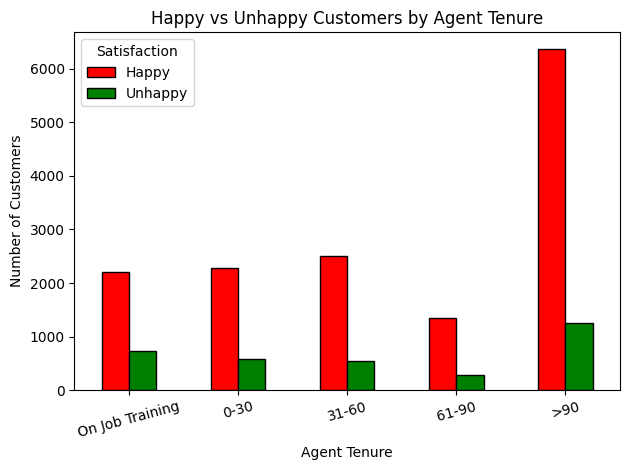

In [63]:
#Happy vs Unhappy Customers by Agent Tenure
plt.figure(figsize=(10, 6))

tenure_order = ['On Job Training', '0-30', '31-60', '61-90', '>90']

tenure_sat = df.groupby(['Tenure Bucket', 'Satisfaction'], observed=True).size().unstack().reindex(tenure_order)
tenure_sat.plot(kind='bar', color=['red', 'green'], edgecolor='black')

plt.title('Happy vs Unhappy Customers by Agent Tenure')
plt.xlabel('Agent Tenure')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.legend(title='Satisfaction')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a grouped bar chart ordered by experience level
because it directly shows how agent experience affects the
ratio of happy to unhappy customers across different tenure
buckets.

##### 2. What is/are the insight(s) found from the chart?

Agents with more than 90 days of experience have the highest
ratio of happy to unhappy customers. On Job Training agents
have the worst ratio meaning they create the most unhappy
customers relative to the number of tickets they handle.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative impact is that OJT agents are clearly not ready
to handle customers independently from day one. Flipkart
should not assign complex or sensitive tickets to new agents
until they complete proper training. A mentor system pairing
new agents with experienced ones would help bridge this gap
much faster.

####Chart -20

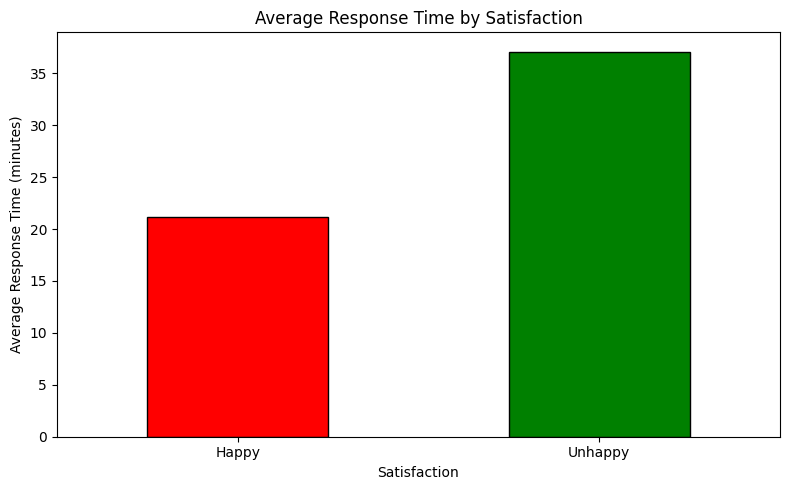

In [64]:
#Average Response Time by Satisfaction
plt.figure(figsize=(8, 5))

df[df['Response_Time_mins'] < 300].groupby('Satisfaction')['Response_Time_mins'].mean().plot(kind='bar', color=['red', 'green'], edgecolor='black')

plt.title('Average Response Time by Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Average Response Time (minutes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

I picked a simple two bar chart because it directly compares
average response time between happy and unhappy customers
making the relationship between waiting time and satisfaction
immediately obvious.

##### 2. What is/are the insight(s) found from the chart?

Unhappy customers waited significantly longer on average
compared to happy customers. This is the clearest and most
direct finding in the entire project and strongly confirms
that response time is a key driver of customer satisfaction.

#####3 . Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This is the single most actionable finding in the whole
project. If Flipkart can reduce response times across all
tickets the proportion of unhappy customers will drop
directly. Setting a maximum response time target of 20
minutes with real time supervisor alerts when tickets
exceed this limit would be a strong and immediate first step.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Here are the recommendations for Flipkart, based on our exploratory data analysis of 85,907 Flipkart customer support tickets, aimed at boosting customer satisfaction scores:

1. Enhance Agent Onboarding and Training
On Job Training agents consistently underperformed with the lowest CSAT scores. We recommend implementing a structured buddy system, where new agents are assigned a senior agent (over 90-day tenure) for the initial 30 days. This addresses a key controllable contributor to CSAT and expedites agent readiness.

2. Implement a Strict Response Time Target
Customer satisfaction declined significantly with longer waiting times for agent response. Flipkart should enforce a 20-minute maximum response time across all tickets. Supervisors should be alerted when tickets are nearing the deadline, enabling timely intervention and preventing customer frustration.

3. Optimize Night Shift Staffing
Night shifts, particularly with new agents, yielded the lowest CSAT. We suggest assigning experienced agents to night shifts exclusively and eliminating On Job Training agents from this segment. A dedicated night shift escalation queue for complex issues would further improve the experience.

4. Develop a Reverse Pickup Tracking Feature
A common sub-category across tickets was Reverse Pickup Enquiry, where customers were calling to track returns. A real-time reverse pickup tracking feature, similar to existing forward delivery tracking within the app, would drastically reduce these agentless tickets.

5. Improve Training for GiftCard, Offers, and Cashback Issues
The GiftCard and Offers and Cashback categories demonstrated below-average satisfaction scores, indicating a need for enhanced agent knowledge. Implementing standardized decision trees and clearer policies for these areas would lead to more consistent and satisfactory resolutions.

6. Enhance Email Support
Email exhibited the lowest average CSAT of all channels. We recommend evaluating the email support process for potential improvements in response times, personalization, and email templates for common issues.

# **Conclusion**

For this project I analyzed 85,907 Flipkart customer support tickets to discover factors influencing customer satisfaction scores. With some cleaning and feature engineering and a total of 20 charts I found several important things.

Agent experience is by far the biggest driver of customer satisfaction. Agents over 90 days experience scored significantly higher than OJT agents. It would be beneficial for Flipkart to improve the onboarding and training process to help new agents gain experience and score higher quicker.

The second biggest factor was response time. Customers who were answered quickly rated their satisfaction much higher than those who were forced to wait and customers who waited long responded lower. Multiple charts backed this up and this can be clearly seen in the correlation heatmap as well as the response time bucket chart. Flipkart should consider having an ambitious target for response times.

It was interesting to find that the combination of a new agent and night shift yielded the worst satisfaction in the entire dataset and so this should be avoided in the future.

Returns and Order Related issues represented nearly 78% of support tickets. Reducing friction in the returns process and allowing customers self service tools such as reverse pickup tracking will greatly decrease this volume of tickets.

In summary, Flipkart can improve customer satisfaction without revolutionary changes to their process. Adjusting training, focusing on response times, improving shifts for new agents, and increasing self service options will allow Flipkart to obtain a significantly more satisfied customer base.

This project allowed me to realize the power of data analysis in business applications and how one can find unseen trends and make them tangible through EDA.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***